# Q-learning 算法在网格世界中的路径规划

## 实验目标
理解 Q-learning 中**探索与利用的平衡**，掌握强化学习核心参数（学习率 α、折扣因子 γ、探索率 ε）对学习效果的影响。

## 实验环境
- **5×5 网格世界**：起点 (0,0)，目标 (4,4)
- **动作空间**：上、下、左、右
- **奖励机制**：碰壁 -1，到达目标 +10，其他 -0.1

## Q-learning 算法原理

Q-learning 是一种无模型的时序差分（TD）强化学习算法，核心更新公式：

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

其中 α 控制新旧信息权重，γ 控制未来奖励的折扣程度。

## 1. 导入库与网格环境构建

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
matplotlib.rcParams["axes.unicode_minus"] = False

np.random.seed(42)

In [2]:
class GridWorld:
    """5×5 网格世界环境"""
    
    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)
        self.state = self.start
        # 动作映射：0=上, 1=下, 2=左, 3=右
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        self.n_actions = len(self.actions)
    
    def reset(self):
        self.state = self.start
        return self.state
    
    def step(self, action):
        """执行动作，返回 (next_state, reward, done)"""
        r, c = self.state
        dr, dc = self.actions[action]
        nr, nc = r + dr, c + dc
        
        if nr < 0 or nr >= self.size or nc < 0 or nc >= self.size:
            # 碰壁：留在原地
            next_state = self.state
            reward = -1.0
        else:
            next_state = (nr, nc)
            if next_state == self.goal:
                reward = 10.0
            else:
                reward = -0.1
        
        self.state = next_state
        done = (self.state == self.goal)
        return next_state, reward, done
    
    def render_path(self, path):
        """在网格上绘制路径"""
        grid = np.zeros((self.size, self.size))
        for i, (r, c) in enumerate(path):
            grid[r, c] = i + 1
        return grid

In [3]:
# 测试环境基本功能
env = GridWorld(size=5)
print(f"网格大小: {env.size}×{env.size}")
print(f"起点: {env.start}")
print(f"目标: {env.goal}")
print(f"动作数: {env.n_actions}")

# 测试碰壁
env.reset()
_, r, _ = env.step(0)  # 向上（碰壁）
print(f"起点向上（碰壁）奖励: {r}")

网格大小: 5×5
起点: (0, 0)
目标: (4, 4)
动作数: 4
起点向上（碰壁）奖励: -1.0


## 2. Q-learning 算法实现

In [4]:
class QLearning:
    """Q-learning 智能体"""
    
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha    # 学习率
        self.gamma = gamma    # 折扣因子
        self.epsilon = epsilon  # 探索率
        self.Q = defaultdict(lambda: np.zeros(env.n_actions))
    
    def choose_action(self, state):
        """ε-greedy 策略选择动作"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.env.n_actions)  # 探索
        else:
            return np.argmax(self.Q[state])  # 利用
    
    def learn(self, state, action, reward, next_state, done):
        """Q值更新"""
        q_current = self.Q[state][action]
        q_target = reward + self.gamma * np.max(self.Q[next_state]) * (1 - done)
        self.Q[state][action] += self.alpha * (q_target - q_current)
    
    def get_policy_path(self):
        """按贪婪策略走出一条路径（用于可视化）"""
        state = self.env.reset()
        path = [state]
        visited = set()
        
        for _ in range(self.env.size * self.env.size):
            if state == self.env.goal:
                break
            action = np.argmax(self.Q[state])
            next_state, _, done = self.env.step(action)
            if next_state in visited:  # 防止死循环
                break
            visited.add(next_state)
            path.append(next_state)
            state = next_state
            if done:
                break
        return path

In [5]:
def train(env, agent, n_episodes=1000, max_steps=50):
    """训练智能体，返回每回合总奖励"""
    episode_rewards = []
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        
        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if done:
                break
        
        episode_rewards.append(total_reward)
    
    return episode_rewards

## 3. 基准参数训练与结果分析

In [6]:
# 基准参数：α=0.1, γ=0.9, ε=0.1
env_base = GridWorld(size=5)
agent_base = QLearning(env_base, alpha=0.1, gamma=0.9, epsilon=0.1)

print("开始训练（基准参数 α=0.1, γ=0.9, ε=0.1）...")
rewards_base = train(env_base, agent_base, n_episodes=1000, max_steps=50)
print("训练完成！")
print(f"前100回合平均奖励: {np.mean(rewards_base[:100]):.2f}")
print(f"后100回合平均奖励: {np.mean(rewards_base[-100:]):.2f}")
print(f"最高回合奖励: {np.max(rewards_base):.2f}")

开始训练（基准参数 α=0.1, γ=0.9, ε=0.1）...
训练完成！
前100回合平均奖励: 8.06
后100回合平均奖励: 9.11
最高回合奖励: 9.30


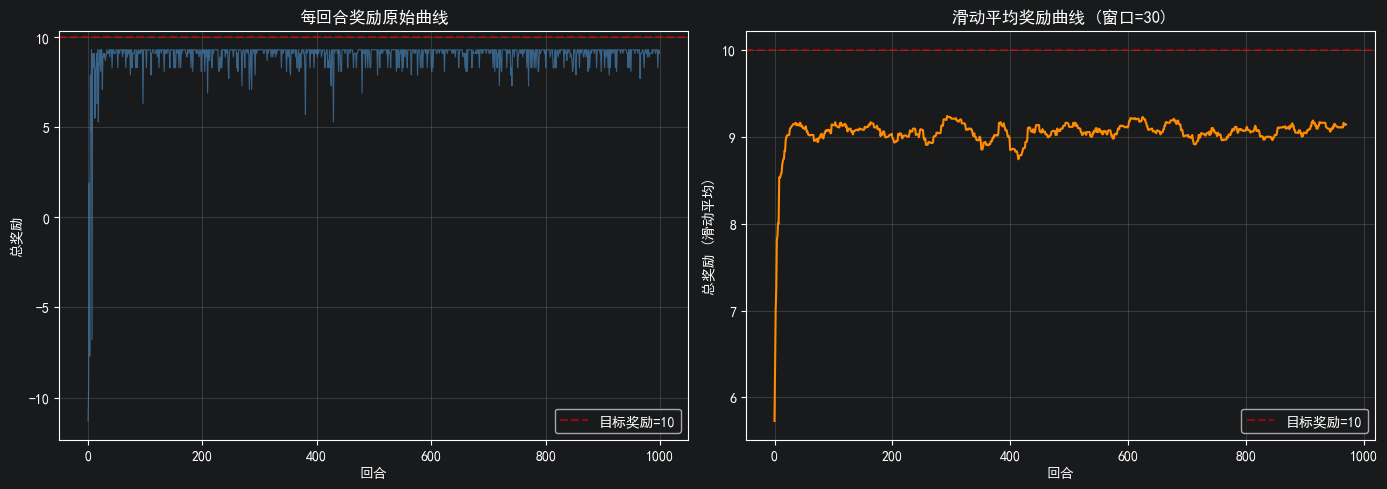

In [7]:
# 绘制奖励随回合的变化曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 原始曲线
ax1.plot(rewards_base, linewidth=0.8, color="steelblue", alpha=0.7)
ax1.axhline(y=10, color="r", linestyle="--", alpha=0.5, label="目标奖励=10")
ax1.set_xlabel("回合")
ax1.set_ylabel("总奖励")
ax1.set_title("每回合奖励原始曲线")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 平滑曲线（滑动平均）
window = 30
rewards_smooth = np.convolve(rewards_base, np.ones(window)/window, mode="valid")

ax2.plot(rewards_smooth, linewidth=1.5, color="darkorange")
ax2.axhline(y=10, color="r", linestyle="--", alpha=0.5, label="目标奖励=10")
ax2.set_xlabel("回合")
ax2.set_ylabel("总奖励 (滑动平均)")
ax2.set_title(f"滑动平均奖励曲线 (窗口={window})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

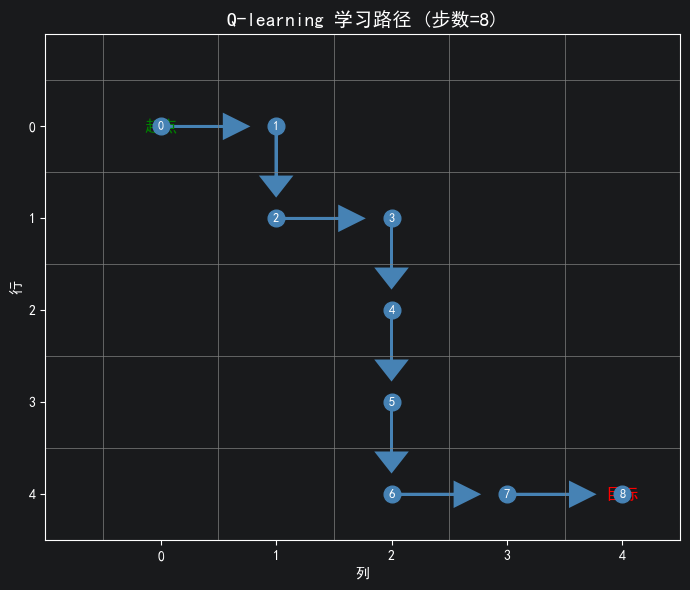

路径步数: 8
路径坐标: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]


In [8]:
# 可视化最终学习到的路径
path_base = agent_base.get_policy_path()

fig, ax = plt.subplots(figsize=(7, 6))

# 绘制网格
for i in range(env_base.size + 1):
    ax.axhline(i - 0.5, color="gray", linewidth=0.5)
    ax.axvline(i - 0.5, color="gray", linewidth=0.5)

# 标注起点和终点
ax.text(0, 0, "起点", ha="center", va="center", fontsize=12, fontweight="bold", color="green")
ax.text(4, 4, "目标", ha="center", va="center", fontsize=12, fontweight="bold", color="red")

# 绘制路径箭头
for i in range(len(path_base) - 1):
    r1, c1 = path_base[i]
    r2, c2 = path_base[i + 1]
    ax.arrow(c1, r1, (c2 - c1) * 0.75, (r2 - r1) * 0.75,
             head_width=0.25, head_length=0.2, fc="steelblue", ec="steelblue",
             linewidth=2, length_includes_head=True)

# 标注步数
for i, (r, c) in enumerate(path_base):
    ax.plot(c, r, "o", color="steelblue", markersize=12, zorder=3)
    ax.text(c, r, str(i), ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax.set_xlim(-1, env_base.size - 0.5)
ax.set_ylim(env_base.size - 0.5, -1)
ax.set_xticks(range(env_base.size))
ax.set_yticks(range(env_base.size))
ax.set_xlabel("列")
ax.set_ylabel("行")
ax.set_title(f"Q-learning 学习路径 (步数={len(path_base)-1})", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("final_path.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"路径步数: {len(path_base) - 1}")
print(f"路径坐标: {path_base}")

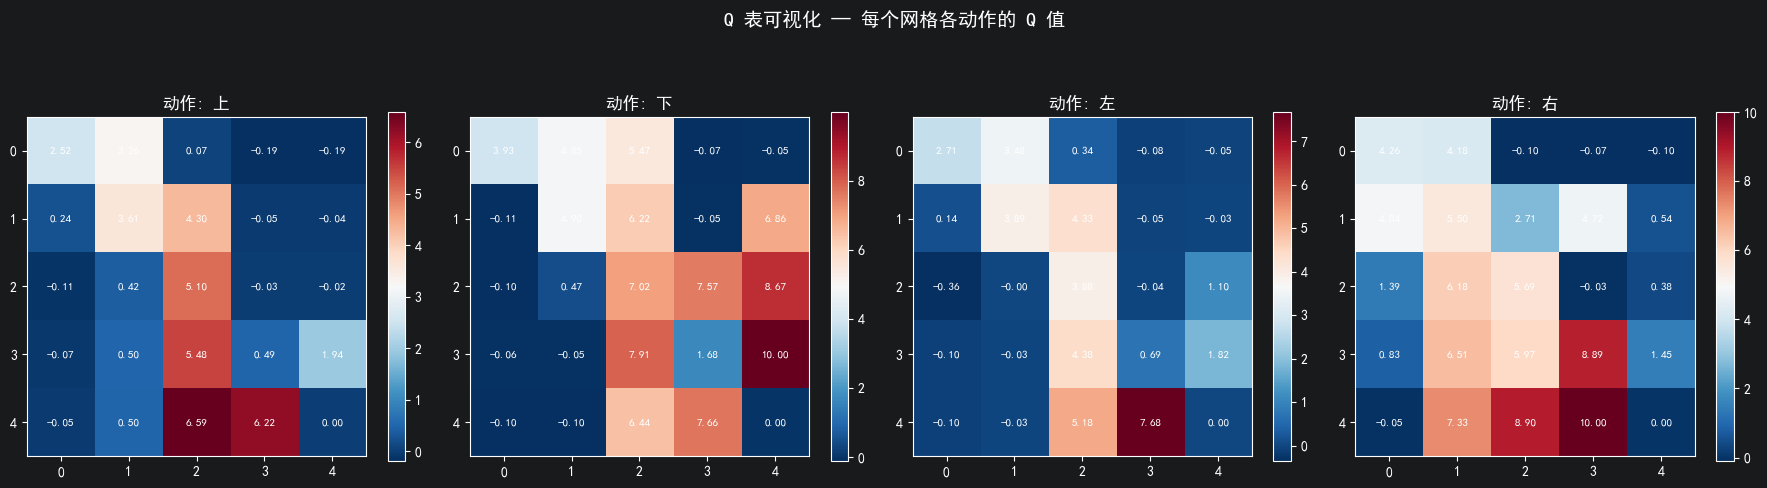

In [9]:
# 展示最终 Q 表热力图
action_names = ["上", "下", "左", "右"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Q 表可视化 — 每个网格各动作的 Q 值", fontsize=14, fontweight="bold", y=1.02)

for a_idx, (ax, a_name) in enumerate(zip(axes, action_names)):
    q_grid = np.zeros((env_base.size, env_base.size))
    for r in range(env_base.size):
        for c in range(env_base.size):
            q_grid[r, c] = agent_base.Q[(r, c)][a_idx]
    
    im = ax.imshow(q_grid, cmap="RdBu_r", aspect="equal")
    ax.set_title(f"动作: {a_name}")
    ax.set_xticks(range(env_base.size))
    ax.set_yticks(range(env_base.size))
    for r in range(env_base.size):
        for c in range(env_base.size):
            ax.text(c, r, f"{q_grid[r,c]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig("q_table_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 参数对比实验

比较不同 (α, γ) 组合对收敛速度的影响。

In [10]:
# 定义参数组合
param_sets = [
    (0.1, 0.9, "α=0.1, γ=0.9 (基准)"),
    (0.2, 0.9, "α=0.2, γ=0.9 (高学习率)"),
    (0.1, 0.5, "α=0.1, γ=0.5 (低折扣)"),
    (0.2, 0.5, "α=0.2, γ=0.5"),
    (0.5, 0.9, "α=0.5, γ=0.9 (极高学习率)"),
]

all_rewards = {}

print("训练不同参数组合...\n")
for alpha, gamma, label in param_sets:
    env = GridWorld(size=5)
    agent = QLearning(env, alpha=alpha, gamma=gamma, epsilon=0.1)
    rewards = train(env, agent, n_episodes=1000, max_steps=50)
    all_rewards[label] = rewards
    print(f"{label}: 前100均={np.mean(rewards[:100]):.2f}, 后100均={np.mean(rewards[-100:]):.2f}, 最高={np.max(rewards):.2f}")

训练不同参数组合...

α=0.1, γ=0.9 (基准): 前100均=8.20, 后100均=9.15, 最高=9.30
α=0.2, γ=0.9 (高学习率): 前100均=8.45, 后100均=9.09, 最高=9.30
α=0.1, γ=0.5 (低折扣): 前100均=8.14, 后100均=9.09, 最高=9.30
α=0.2, γ=0.5: 前100均=8.22, 后100均=9.01, 最高=9.30
α=0.5, γ=0.9 (极高学习率): 前100均=8.54, 后100均=9.02, 最高=9.30


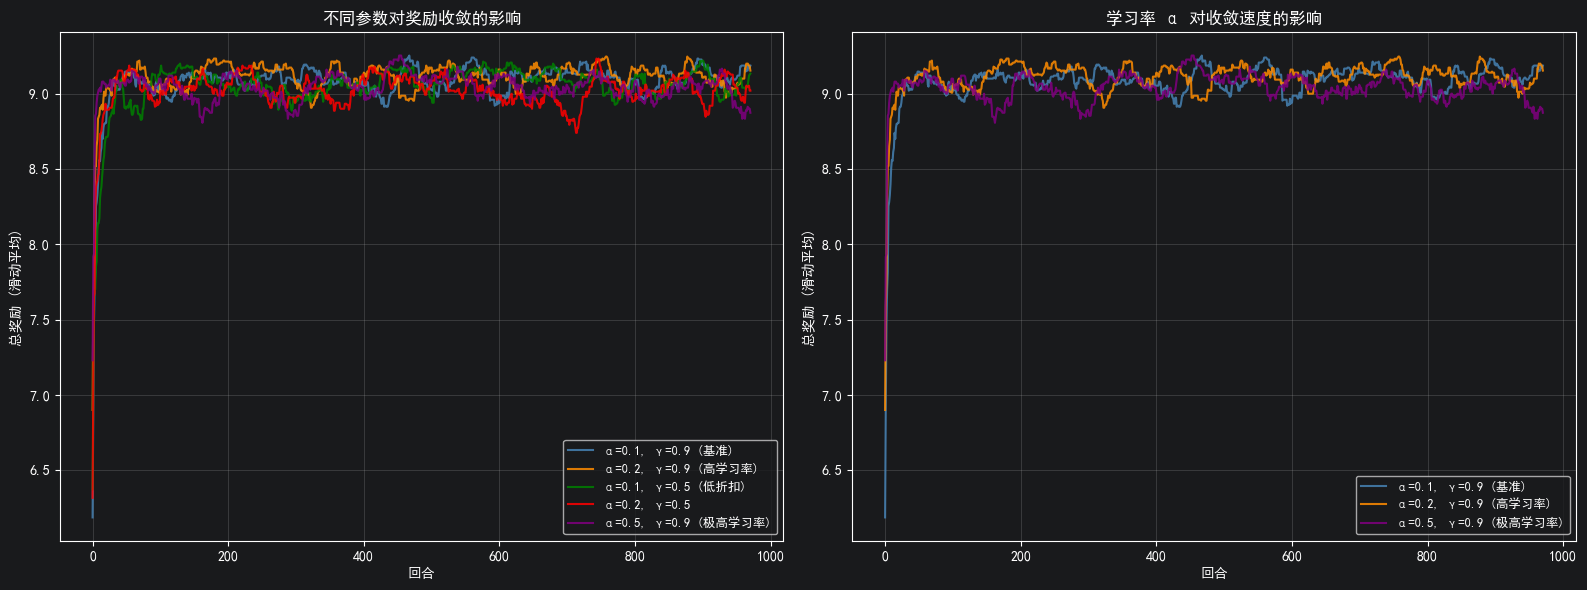

In [11]:
# 绘制不同参数奖励曲线对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ["steelblue", "darkorange", "green", "red", "purple"]
window = 30

for (label, rewards), color in zip(all_rewards.items(), colors):
    smooth = np.convolve(rewards, np.ones(window)/window, mode="valid")
    ax1.plot(smooth, linewidth=1.5, color=color, label=label, alpha=0.85)

ax1.set_xlabel("回合")
ax1.set_ylabel("总奖励 (滑动平均)")
ax1.set_title("不同参数对奖励收敛的影响")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 学习率对比
alpha_sets = [
    ("α=0.1, γ=0.9 (基准)", "steelblue"),
    ("α=0.2, γ=0.9 (高学习率)", "darkorange"),
    ("α=0.5, γ=0.9 (极高学习率)", "purple"),
]
for label, color in alpha_sets:
    smooth = np.convolve(all_rewards[label], np.ones(window)/window, mode="valid")
    ax2.plot(smooth, linewidth=1.5, color=color, label=label, alpha=0.85)

ax2.set_xlabel("回合")
ax2.set_ylabel("总奖励 (滑动平均)")
ax2.set_title("学习率 α 对收敛速度的影响")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("param_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

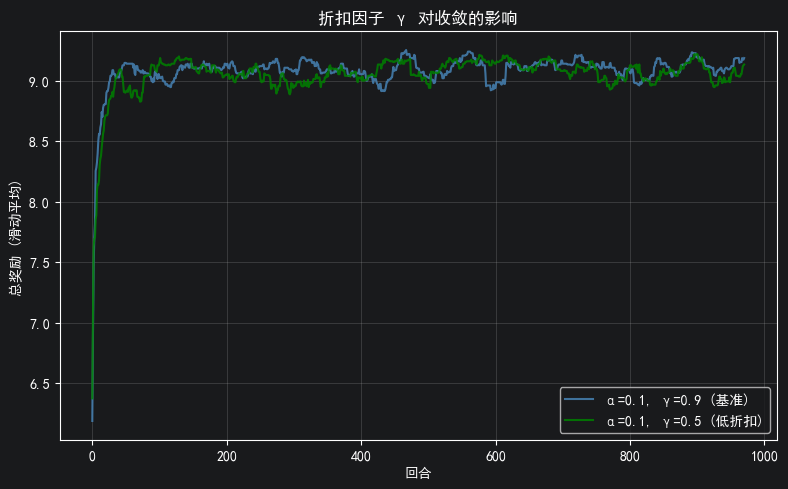

In [12]:
# 折扣因子 γ 对比
fig, ax = plt.subplots(figsize=(8, 5))

gamma_sets = [
    ("α=0.1, γ=0.9 (基准)", "steelblue"),
    ("α=0.1, γ=0.5 (低折扣)", "green"),
]
for label, color in gamma_sets:
    smooth = np.convolve(all_rewards[label], np.ones(window)/window, mode="valid")
    ax.plot(smooth, linewidth=1.5, color=color, label=label, alpha=0.85)

ax.set_xlabel("回合")
ax.set_ylabel("总奖励 (滑动平均)")
ax.set_title("折扣因子 γ 对收敛的影响")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. ε-greedy 探索率对比

In [13]:
# 固定 α=0.1, γ=0.9，比较不同 ε
epsilon_sets = [0.01, 0.1, 0.3]
epsilon_rewards = {}

print("不同探索率 ε 对比:\n")
for eps in epsilon_sets:
    env = GridWorld(size=5)
    agent = QLearning(env, alpha=0.1, gamma=0.9, epsilon=eps)
    rewards = train(env, agent, n_episodes=1000, max_steps=50)
    epsilon_rewards[f"ε={eps}"] = rewards
    print(f"ε={eps}: 前100均={np.mean(rewards[:100]):.2f}, 后100均={np.mean(rewards[-100:]):.2f}, 最高={np.max(rewards):.2f}")

不同探索率 ε 对比:

ε=0.01: 前100均=8.48, 后100均=9.30, 最高=9.30
ε=0.1: 前100均=8.14, 后100均=8.98, 最高=9.30
ε=0.3: 前100均=7.63, 后100均=8.31, 最高=9.30


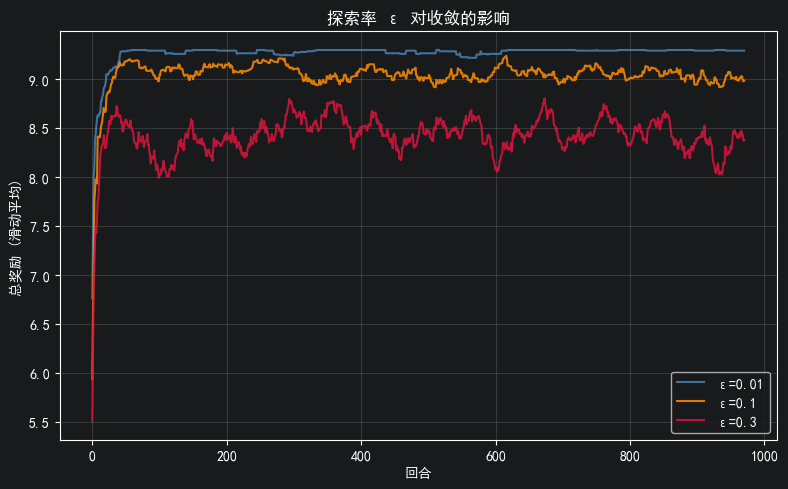

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

colors_eps = ["steelblue", "darkorange", "crimson"]
for (label, rewards), color in zip(epsilon_rewards.items(), colors_eps):
    smooth = np.convolve(rewards, np.ones(window)/window, mode="valid")
    ax.plot(smooth, linewidth=1.5, color=color, label=label, alpha=0.85)

ax.set_xlabel("回合")
ax.set_ylabel("总奖励 (滑动平均)")
ax.set_title("探索率 ε 对收敛的影响")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 探索与利用平衡分析

In [15]:
# 统计训练过程中探索 vs 利用的次数
env_stat = GridWorld(size=5)
agent_stat = QLearning(env_stat, alpha=0.1, gamma=0.9, epsilon=0.1)

explore_count = 0
exploit_count = 0
total_steps = 0

for ep in range(1000):
    state = env_stat.reset()
    for step in range(50):
        if np.random.random() < 0.1:
            action = np.random.randint(4)
            explore_count += 1
        else:
            action = np.argmax(agent_stat.Q[state])
            exploit_count += 1
        total_steps += 1
        next_state, reward, done = env_stat.step(action)
        agent_stat.learn(state, action, reward, next_state, done)
        state = next_state
        if done:
            break

print("=" * 50)
print("        探索与利用统计分析")
print("=" * 50)
print(f"总步数: {total_steps}")
print(f"探索次数: {explore_count} ({explore_count/total_steps*100:.1f}%)")
print(f"利用次数: {exploit_count} ({exploit_count/total_steps*100:.1f}%)")
print()
print("探索与利用的平衡原理:")
print("  ε=0.1 表示 10% 随机探索 + 90% 贪婪利用")
print("  探索过多 → 收敛慢，奖励波动大")
print("  利用过多 → 可能陷入局部最优，无法发现更好策略")
print("=" * 50)

        探索与利用统计分析
总步数: 9194
探索次数: 902 (9.8%)
利用次数: 8292 (90.2%)

探索与利用的平衡原理:
  ε=0.1 表示 10% 随机探索 + 90% 贪婪利用
  探索过多 → 收敛慢，奖励波动大
  利用过多 → 可能陷入局部最优，无法发现更好策略


## 7. 不同参数组合下最终路径对比

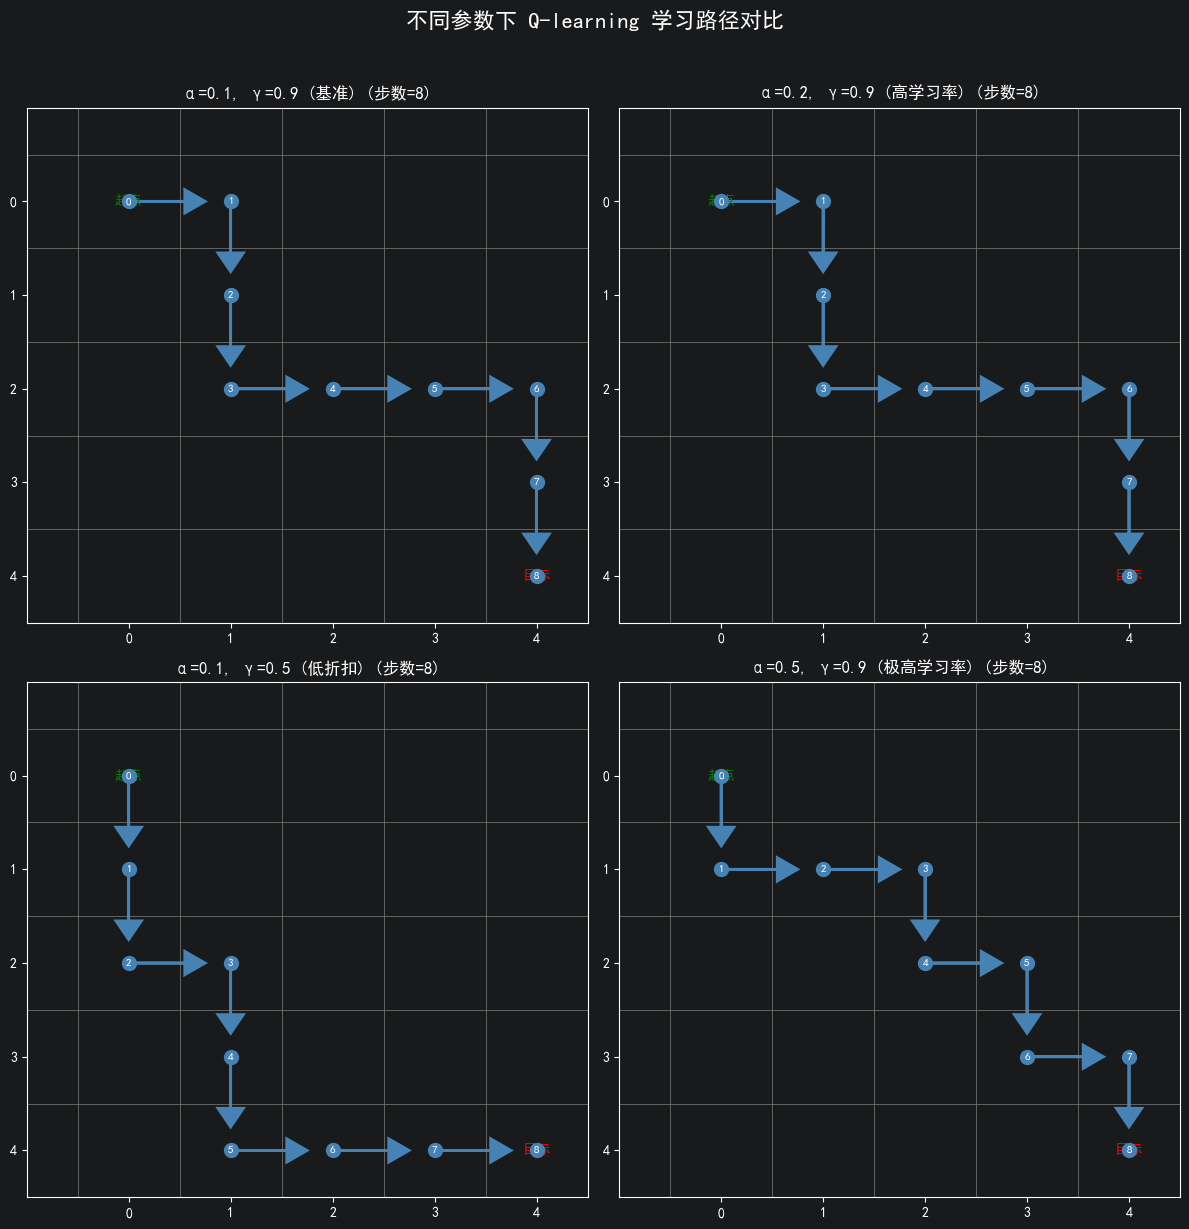

In [16]:
# 绘制不同参数下的最终路径
path_labels = [
    "α=0.1, γ=0.9 (基准)",
    "α=0.2, γ=0.9 (高学习率)",
    "α=0.1, γ=0.5 (低折扣)",
    "α=0.5, γ=0.9 (极高学习率)",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for idx, (label, ax) in enumerate(zip(path_labels, axes.flat)):
    env = GridWorld(size=5)
    agent = QLearning(env, alpha=0.2 if "α=0.2" in label else 0.5 if "α=0.5" in label else 0.1,
                      gamma=0.5 if "γ=0.5" in label else 0.9, epsilon=0.1)
    train(env, agent, n_episodes=1000, max_steps=50)
    path = agent.get_policy_path()
    
    # 绘制网格
    for i in range(env.size + 1):
        ax.axhline(i - 0.5, color="gray", linewidth=0.5)
        ax.axvline(i - 0.5, color="gray", linewidth=0.5)
    
    ax.text(0, 0, "起点", ha="center", va="center", fontsize=10, fontweight="bold", color="green")
    ax.text(4, 4, "目标", ha="center", va="center", fontsize=10, fontweight="bold", color="red")
    
    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i + 1]
        ax.arrow(c1, r1, (c2 - c1) * 0.75, (r2 - r1) * 0.75,
                 head_width=0.25, head_length=0.2, fc="steelblue", ec="steelblue",
                 linewidth=2, length_includes_head=True)
    
    for i, (r, c) in enumerate(path):
        ax.plot(c, r, "o", color="steelblue", markersize=10, zorder=3)
        ax.text(c, r, str(i), ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    
    ax.set_xlim(-1, env.size - 0.5)
    ax.set_ylim(env.size - 0.5, -1)
    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.set_title(f"{label} (步数={len(path)-1})", fontsize=12)

plt.suptitle("不同参数下 Q-learning 学习路径对比", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("path_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 总结

本次实验实现并分析了 Q-learning 算法在网格世界中的路径规划，主要发现：

### 1. 算法收敛性
- Q-learning 能有效学习从起点到目标的最优路径
- 训练初期奖励较低（探索为主），后期逐步上升并收敛（利用为主）

### 2. 参数影响
- **学习率 α**：α 过大导致 Q 值震荡，收敛不稳定；α 过小则学习缓慢
- **折扣因子 γ**：γ 越大越重视长期回报，路径规划更优；γ 过小只看眼前奖励，难以学到完整路径
- **探索率 ε**：ε 太小探索不足可能陷入局部最优；ε 太大浪费步数、收敛慢

### 3. 探索与利用平衡
- ε-greedy 策略通过概率 ε 随机探索、概率 1-ε 贪婪利用来平衡
- 合理的 ε 值（约 0.1）能在探索与利用之间取得良好折中

### 4. 结论
在 5×5 网格世界中，α=0.1, γ=0.9, ε=0.1 是一组较为理想的参数设置，能在 1000 回合内稳定学习到最优路径。